# Perform single-cell quality control

In this notebook, we perform single-cell quality control using coSMicQC. We filter the single cells by identifying outliers with z-scores, and use either combinations of features or one feature for each condition. 

In [1]:
import pathlib
import json

import matplotlib

matplotlib.use("Agg")  # Ensures no GUI windows are opened
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from cosmicqc import find_outliers
from cytodataframe import CytoDataFrame


## Set paths and variables

In [2]:
# Set parameters for papermill to use for processing
plate_id = "CARD-CelIns-CX7_260803130001"


In [3]:
# Directory with data
data_dir = pathlib.Path("./data/converted_profiles/").resolve(strict=True)

# Directory to save qc labeled data
qc_labeled_dir = pathlib.Path("./data/qc_labeled_profiles/")
qc_labeled_dir.mkdir(parents=True, exist_ok=True)

# Directory to save qc figures
qc_fig_dir = pathlib.Path("./qc_figures/")
qc_fig_dir.mkdir(parents=True, exist_ok=True)

# Load only the thresholds for the plate_id in the sc_qc_thresholds.json file
qc_thresholds_path = pathlib.Path("./sc_qc_thresholds.json").resolve(strict=True)
with open(qc_thresholds_path) as f:
    qc_thresholds = json.load(f)
qc_thresholds = qc_thresholds.get(plate_id, {})
print(
    f"Loaded QC thresholds for {len(qc_thresholds)} conditions from {qc_thresholds_path}"
)

# Metadata columns to include in output data frame (based on compartment)
nuclei_metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
    "Image_PathName_OrigDNA",
    "Image_FileName_OrigDNA",
    "Image_PathName_OrigActin",
    "Image_FileName_OrigActin",
    "Nuclei_AreaShape_BoundingBoxMaximum_X",
    "Nuclei_AreaShape_BoundingBoxMaximum_Y",
    "Nuclei_AreaShape_BoundingBoxMinimum_X",
    "Nuclei_AreaShape_BoundingBoxMinimum_Y",
]
cells_metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Cells_Location_Center_X",
    "Metadata_Cells_Location_Center_Y",
    "Image_PathName_OrigDNA",
    "Image_FileName_OrigDNA",
    "Image_PathName_OrigActin",
    "Image_FileName_OrigActin",
    "Cells_AreaShape_BoundingBoxMaximum_X",
    "Cells_AreaShape_BoundingBoxMaximum_Y",
    "Cells_AreaShape_BoundingBoxMinimum_X",
    "Cells_AreaShape_BoundingBoxMinimum_Y",
]


Loaded QC thresholds for 5 conditions from /home/jenna/targeted_fibrosis_drug_screen/5.validation_plate/2.preprocessing_features/sc_qc_thresholds.json


## Load in plate to perform QC on

In [4]:
# Set plate path
plate_path = pathlib.Path(f"{data_dir}/{plate_id}_converted.parquet").resolve(
    strict=True
)

# Load the converted plate data
plate_df = pd.read_parquet(plate_path)

# Print the shape of the DataFrame for each plate
print(f"Loaded plate: {plate_path.stem}, Shape: {plate_df.shape}")


Loaded plate: CARD-CelIns-CX7_260803130001_converted, Shape: (8944, 2486)


## Confirm image paths

In [5]:
# Confirm image paths already point to valid local files (no remapping needed for this plate)
example_path = pathlib.Path(
    plate_df["Image_PathName_OrigDNA"].dropna().iloc[0]
) / plate_df["Image_FileName_OrigDNA"].dropna().iloc[0]
if not example_path.is_file():
    raise FileNotFoundError(f"Example image path does not exist: {example_path}")

# Print example image path
print(plate_df["Image_PathName_OrigDNA"].dropna().iloc[0])


/home/jenna/mnt/Way_McKinsey_Cardiac_Fibrosis/Compound_Screen/hit_validation_cell_painting/CARD-CelIns-CX7_260803130001


In [6]:
# Print example image file
print(plate_df["Image_FileName_OrigDNA"].dropna().iloc[0])


CARD-CelIns-CX7_260803130001_B03f09d4.TIF


## Set mapping for outlines

In [7]:
# Define available compartments
compartments = ["Nuclei", "Cells"]

# Create a dictionary of mappings for each compartment.
# The outline TIFFs (e.g. "NucleiOutlines_PLATE_WELL_SITE.tiff") use the raw,
# unpadded site number. The original images (e.g. "PLATE_WELLf09d4.TIF") use an
# "f"-prefixed, zero-padded site token, a channel digit, and an uppercase ".TIF"
# extension, so the original-image regex has to be built to match that format
# (case-insensitively) rather than reusing the outline's site formatting.
mapping_dict = {
    comp: {
        rf"{comp}Outlines_{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Site']}.tiff": (
            rf"(?i){record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}"
            rf"f{int(record['Image_Metadata_Site']):02d}d\d\.tif"
        )
        for record in plate_df[
            ["Image_Metadata_Plate", "Image_Metadata_Well", "Image_Metadata_Site"]
        ].to_dict(orient="records")
    }
    for comp in compartments
}


## Detect over-segmented nuclei using shape and intensity

In [8]:
# Set mapping for Nuclei compartment
outline_to_orig_mapping = mapping_dict["Nuclei"]


Number of outliers: 99 (1.11%)
Outliers Range:
Nuclei_AreaShape_Solidity Min: 0.7104766696013081
Nuclei_AreaShape_Solidity Max: 0.9665809768637532
Nuclei_Intensity_MassDisplacement_DNA Min: 1.0526652497808044
Nuclei_Intensity_MassDisplacement_DNA Max: 12.15143280145672


,Nuclei_AreaShape_Solidity,Nuclei_Intensity_MassDisplacement_DNA,Image_FileName_OrigDNA
1450,0.748652,12.151433,
4174,0.960530,6.376596,
6253,0.892297,5.029808,
8055,0.789981,4.376470,
6873,0.938889,4.091654,

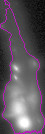
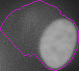
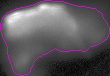

In [9]:
# Find large nuclei outliers for the current plate
oversegmented_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=nuclei_metadata_columns,
    feature_thresholds=qc_thresholds.get("oversegmented_nuclei", {}),
)

# Convert to CytoDataFrame for outline viewing
oversegmented_nuclei_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(oversegmented_nuclei_outliers),
    data_outline_context_dir=f"../1.cellprofiler_processing/cp_output/{plate_id}/",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": False,
        "brightness": 5,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Nuclei_AreaShape_Solidity",
        "Nuclei_Intensity_MassDisplacement_DNA",
        "Image_FileName_OrigDNA",
    ]
]

oversegmented_nuclei_outliers_cdf.sort_values(
    by="Nuclei_Intensity_MassDisplacement_DNA", ascending=False
).head(5)


## Detect mis-segmented background as nuclei

Number of outliers: 32 (0.36%)
Outliers Range:
Nuclei_Intensity_MeanIntensity_DNA Min: 0.02369558120730753
Nuclei_Intensity_MeanIntensity_DNA Max: 0.03809781576353304


,Nuclei_Intensity_MeanIntensity_DNA,Image_FileName_OrigDNA
2102,0.038098,
1588,0.038089,
8911,0.037910,
4252,0.037516,
4539,0.037498,

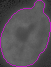
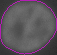
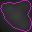
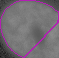
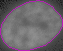

In [10]:
# Find low intensity nuclei outliers for the current plate
low_intensity_outliers = find_outliers(
    df=plate_df,
    metadata_columns=nuclei_metadata_columns,
    feature_thresholds=qc_thresholds.get("low_intensity_nuclei", {}),
)

# Convert to CytoDataFrame for outline viewing
low_intensity_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(low_intensity_outliers),
    data_outline_context_dir=f"../1.cellprofiler_processing/cp_output/{plate_id}/",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": False,
        "brightness": 5,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Nuclei_Intensity_MeanIntensity_DNA",
        "Image_FileName_OrigDNA",
    ]
]

low_intensity_outliers_cdf.sort_values(
    by="Nuclei_Intensity_MeanIntensity_DNA", ascending=False
).head(5)


## Detect under-segmented cells

### Set up outlines for cells

In [11]:
# Set mapping for Cells compartment
outline_to_orig_mapping = mapping_dict["Cells"]


Number of outliers: 70 (0.78%)
Outliers Range:
Cells_AreaShape_Area Min: 719.0
Cells_AreaShape_Area Max: 4243.0


,Cells_AreaShape_Area,Image_FileName_OrigActin
7415,4243.0,
8326,4043.0,
1955,3920.0,
5701,3909.0,
8813,3895.0,
258,3874.0,
3590,3846.0,
4090,3734.0,
4881,3725.0,
8904,3670.0,

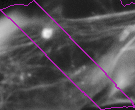
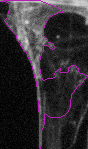
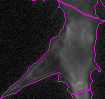
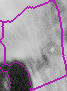
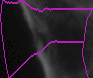
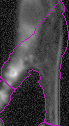
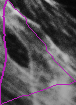
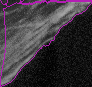
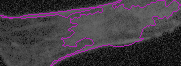
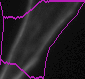

In [12]:
# Find under-segmented cells outliers for the current plate
small_cells_outliers = find_outliers(
    df=plate_df,
    metadata_columns=cells_metadata_columns,
    feature_thresholds=qc_thresholds.get("undersegmented_cells", {}),
)

# Convert to CytoDataFrame for outline viewing
small_cells_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(small_cells_outliers),
    data_outline_context_dir=f"../1.cellprofiler_processing/cp_output/{plate_id}/",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": False,
        "brightness": 5,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Cells_AreaShape_Area",
        "Image_FileName_OrigActin",
    ]
]

small_cells_outliers_cdf.sort_values(
    by="Cells_AreaShape_Area", ascending=False
).head(10)


## Detect out of focus/blurry cells

Number of outliers: 35 (0.39%)
Outliers Range:
Cells_Granularity_1_Actin Min: 8.062219287058518
Cells_Granularity_1_Actin Max: 17.119792261048715


,Cells_Granularity_1_Actin,Image_FileName_OrigActin
1333,8.062219,
2103,9.280200,
7945,11.933826,
2726,12.559392,
5877,12.679214,
6710,12.882776,
5870,13.113596,
7077,13.134330,
4227,13.503669,
2014,13.680204,

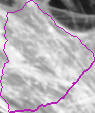
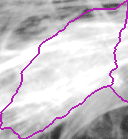
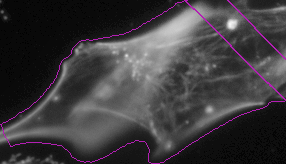
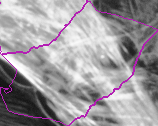
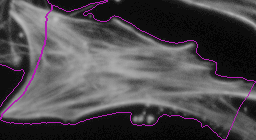
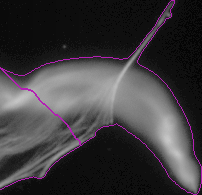
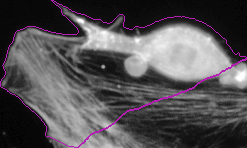
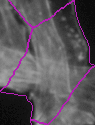
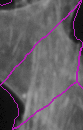
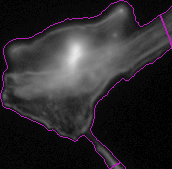

In [13]:
# Find blurry cells outliers for the current plate
blurry_cells_outliers = find_outliers(
    df=plate_df,
    metadata_columns=cells_metadata_columns,
    feature_thresholds=qc_thresholds.get("blurry_cells", {}),
)

# Convert to CytoDataFrame for outline viewing
blurry_cells_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(blurry_cells_outliers),
    data_outline_context_dir=f"../1.cellprofiler_processing/cp_output/{plate_id}/",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": False,
        "brightness": 5,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Cells_Granularity_1_Actin",
        "Image_FileName_OrigActin",
    ]
]

blurry_cells_outliers_cdf.sort_values(
    by="Cells_Granularity_1_Actin", ascending=True
).head(10)


## Detect mis-segmented cells based on number of indentations (solidity)

We have seen that due to low staining in some Actin FOVs that segmentation will mis-segment to include more background than it should.

Number of outliers: 208 (2.33%)
Outliers Range:
Cells_Intensity_MeanIntensity_Actin Min: 0.0010083858972367466
Cells_Intensity_MeanIntensity_Actin Max: 0.002357884063668401
Cells_AreaShape_FormFactor Min: 0.020972148104539467
Cells_AreaShape_FormFactor Max: 0.13104305417357637


,Image_FileName_OrigActin,Cells_Intensity_MeanIntensity_Actin,Cells_AreaShape_FormFactor
273,,0.001008,0.020972
389,,0.001154,0.070644
815,,0.001198,0.100359
1040,,0.001213,0.079351
2078,,0.001219,0.054815
2706,,0.001231,0.102923
1442,,0.001231,0.043499
2844,,0.001257,0.115441
3351,,0.001280,0.106456
4688,,0.001284,0.111222

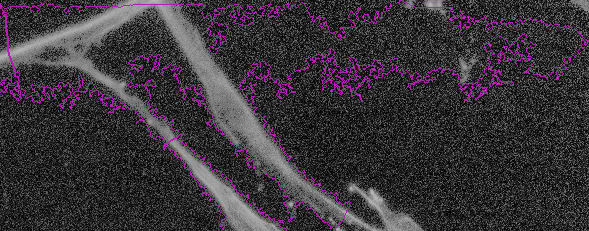
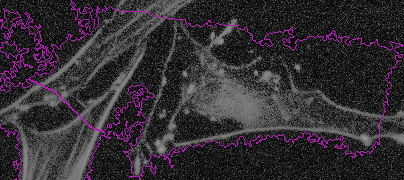
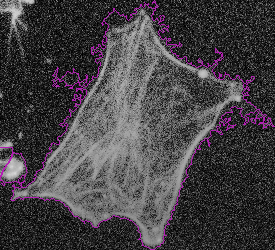
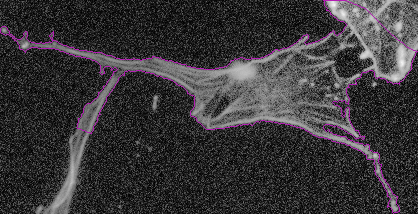
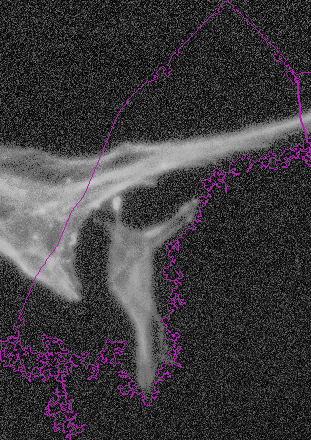
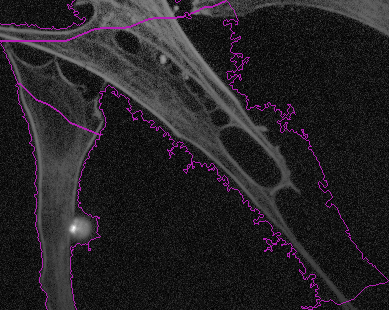
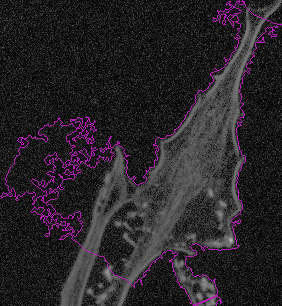
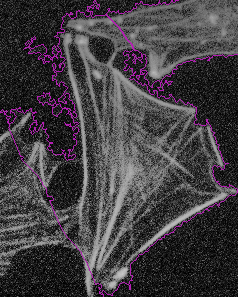
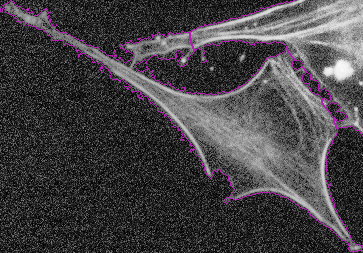
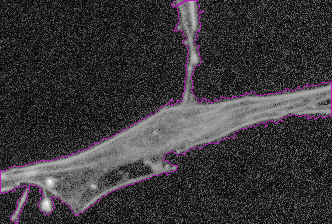

In [14]:
# Find mis-segmented cells outliers for the current plate
missegmented_cells_outliers = find_outliers(
    df=plate_df,
    metadata_columns=cells_metadata_columns,
    feature_thresholds=qc_thresholds.get("missegmented_cells", {}),
)

# Convert to CytoDataFrame for outline viewing
missegmented_cells_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(missegmented_cells_outliers),
    data_outline_context_dir=f"../1.cellprofiler_processing/cp_output/{plate_id}/",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": False,
        "brightness": 1,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Image_FileName_OrigActin",
        "Cells_Intensity_MeanIntensity_Actin",
        "Cells_AreaShape_FormFactor",
    ]
]

missegmented_cells_outliers_cdf.sort_values(
    by="Cells_Intensity_MeanIntensity_Actin", ascending=True
).head(10)


## Label outliers and save data for the plate

In [15]:
# Add QC failure columns
plate_df["Metadata_cqc_failed_oversegmented_nuclei"] = plate_df.index.isin(
    oversegmented_nuclei_outliers.index
)
plate_df["Metadata_cqc_failed_small_cells"] = plate_df.index.isin(
    small_cells_outliers.index
)
plate_df["Metadata_cqc_failed_low_intensity"] = plate_df.index.isin(
    low_intensity_outliers.index
)
plate_df["Metadata_cqc_failed_blurry_cells"] = plate_df.index.isin(
    blurry_cells_outliers.index
)
plate_df["Metadata_cqc_failed_missegmented_cells"] = plate_df.index.isin(
    missegmented_cells_outliers.index
)

# Determine cells that failed any QC condition
qc_fail_cols = [
    "Metadata_cqc_failed_oversegmented_nuclei",
    "Metadata_cqc_failed_small_cells",
    "Metadata_cqc_failed_low_intensity",
    "Metadata_cqc_failed_blurry_cells",
    "Metadata_cqc_failed_missegmented_cells",
]

failed_mask = plate_df[qc_fail_cols].any(axis=1)

# Calculate the total percentage of nuclei that failed QC
total_nuclei = plate_df.shape[0]
total_failed = failed_mask.sum()
percent_failed = (total_failed / total_nuclei) * 100 if total_nuclei > 0 else 0

# Save labeled data for this plate
plate_cleaned_name = plate_df["Image_Metadata_Plate"].iloc[0]
plate_df.to_parquet(f"{qc_labeled_dir}/{plate_cleaned_name}_qc_labeled.parquet")

# Verify the result and include the percentage of failed QC
print(
    f"QC labeled data saved for plate {plate_cleaned_name}. "
    f"Shape: {plate_df.shape}. Total percent nuclei failed QC: {percent_failed:.2f}%"
)


QC labeled data saved for plate CARD-CelIns-CX7_260803130001. Shape: (8944, 2491). Total percent nuclei failed QC: 4.68%


In [16]:
# Set the default value to 'Single-cell passed QC'
plate_df["Outlier_Status"] = "Single-cell passed QC"

# Label each outlier type, excluding small cells
plate_df.loc[
    plate_df.index.isin(oversegmented_nuclei_outliers.index), "Outlier_Status"
] = "Over-segmented nuclei"

plate_df.loc[plate_df.index.isin(low_intensity_outliers.index), "Outlier_Status"] = (
    "Mis-segmented nuclei"
)

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plate_df,
    x="Nuclei_AreaShape_Solidity",
    y="Nuclei_Intensity_MassDisplacement_DNA",
    hue="Outlier_Status",
    palette={
        "Single-cell passed QC": "#006400",
        "Over-segmented nuclei": "#990090",
        "Mis-segmented nuclei": "#D55E00",
    },
    alpha=0.6,
)

# Add threshold lines
plt.axvline(
    x=oversegmented_nuclei_outliers["Nuclei_AreaShape_Solidity"].max(),
    color="r",
    linestyle="--",
    label="Min. threshold for Nuclei Solidity",
)
plt.axhline(
    y=oversegmented_nuclei_outliers["Nuclei_Intensity_MassDisplacement_DNA"].min(),
    color="b",
    linestyle="--",
    label="Min. threshold for Nuclei Mass Displacement",
)

# Add title and labels
plt.title(f"Nuclei Solidity vs. Mass Displacement ({plate_id})")
plt.xlabel("Nuclei Solidity")
plt.ylabel("Nuclei Mass Displacement (DNA)")
plt.tight_layout()

# Show the legend
plt.legend(loc="upper left", bbox_to_anchor=(0, 1.0), prop={"size": 10})

# Save the figure with plate_id in filename
plt.savefig(qc_fig_dir / f"{plate_id}_nuclei_outliers.png", dpi=500)
plt.close()


In [17]:
# Create KDE plot of all cells
plt.figure(figsize=(10, 6))
sns.kdeplot(
    x=plate_df["Cells_AreaShape_Area"],
    fill=True,
    color="#4682B4",  # steel blue
    alpha=0.6,
)

# Add threshold line for small cells
plt.axvline(
    x=small_cells_outliers["Cells_AreaShape_Area"].max(),
    color="r",
    linestyle="--",
    label=f'Small cells threshold: < {small_cells_outliers["Cells_AreaShape_Area"].max():.2f}',
)

# Labels and title
plt.ylabel("Density")
plt.xlabel("Cells Area")
plt.title(f"Distribution of Cell Areas ({plate_id})")
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig(qc_fig_dir / f"{plate_id}_small_cell_outliers.png", dpi=500)
plt.close()
